# T5YIE Text/Role/Event Feature EDA (Phase 3 Feasibility)

This notebook evaluates whether newly added document-level features and event-style monthly sentiment features are promising for future T5YIE modeling experiments.


## 1) Data Sources + Schema Audit

Goals in this section:
- Load target and feature artifacts.
- Prefer the backfilled feature parquet with new document-level columns.
- Assert schema requirements and key integrity assumptions early.


In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.options.display.max_columns = 200


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / '.git').exists():
            return candidate
    raise FileNotFoundError('Repo root not found')


REPO_ROOT = find_repo_root(Path.cwd().resolve())
TARGET_PATH = REPO_ROOT / 'data' / 'targets' / 't5yie_diff1.parquet'
FEATURES_PATH_PRIMARY = REPO_ROOT / 'data' / 'features' / 'doc_level' / 'features_backfilled_with_doc_features.parquet'
FEATURES_PATH_FALLBACK = REPO_ROOT / 'data' / 'features' / 'doc_level' / 'features.parquet'

FEATURES_PATH = FEATURES_PATH_PRIMARY if FEATURES_PATH_PRIMARY.exists() else FEATURES_PATH_FALLBACK

REQ_TARGET = {'date', 't5yie_diff1'}
REQ_BASE_FEATURES = {
    'doc_id', 'source_type', 'date', 'hawkish_score', 'novelty',
    'n_hawkish', 'n_dovish', 'n_neutral', 'n_target_sentences'
}
REQ_NEW_FEATURES = {'text_length_words', 'role', 'target_sentences_ratio'}

assert TARGET_PATH.exists(), f'Missing target parquet: {TARGET_PATH}'
assert FEATURES_PATH.exists(), f'Missing features parquet: {FEATURES_PATH}'

print('repo_root:', REPO_ROOT)
print('target_path:', TARGET_PATH)
print('features_path_selected:', FEATURES_PATH)


repo_root: C:\Users\eladb\OneDrive\Desktop\repos\fomc-forecasting\fomc-forecasting
target_path: C:\Users\eladb\OneDrive\Desktop\repos\fomc-forecasting\fomc-forecasting\data\targets\t5yie_diff1.parquet
features_path_selected: C:\Users\eladb\OneDrive\Desktop\repos\fomc-forecasting\fomc-forecasting\data\features\doc_level\features_backfilled_with_doc_features.parquet


In [3]:
def norm_dates(df: pd.DataFrame, col: str = 'date') -> pd.DataFrame:
    out = df.copy()
    out[col] = pd.to_datetime(out[col], errors='coerce').dt.normalize()
    out = out.dropna(subset=[col]).sort_values(col).reset_index(drop=True)
    return out


target_df = norm_dates(pd.read_parquet(TARGET_PATH), 'date')
features_df = norm_dates(pd.read_parquet(FEATURES_PATH), 'date')

missing_target = REQ_TARGET - set(target_df.columns)
missing_base = REQ_BASE_FEATURES - set(features_df.columns)
missing_new = REQ_NEW_FEATURES - set(features_df.columns)

assert not missing_target, f'Target schema mismatch. Missing: {sorted(missing_target)}'
assert not missing_base, f'Feature schema mismatch (base). Missing: {sorted(missing_base)}'

if missing_new:
    if missing_new:
        raise ValueError(
            f"Selected features parquet does not contain required new columns {sorted(missing_new)}. "
            "Run the backfill workflow or provide a feature parquet with new doc-level columns."
        )

# Core integrity checks
assert target_df['date'].is_monotonic_increasing
assert target_df['date'].is_unique
assert features_df['date'].is_monotonic_increasing

print('target rows:', len(target_df), 'range:', target_df['date'].min().date(), '->', target_df['date'].max().date())
print('features rows:', len(features_df), 'range:', features_df['date'].min().date(), '->', features_df['date'].max().date())
print('source_type counts:')
print(features_df['source_type'].value_counts(dropna=False))

display(target_df.head(3))
display(features_df.head(3))


target rows: 5808 range: 2003-01-03 -> 2026-03-24
features rows: 1695 range: 1994-02-04 -> 2026-03-03
source_type counts:
source_type
speech      1308
document     387
Name: count, dtype: int64


,date,t5yie_diff1
0,2003-01-03,-0.02
1,2003-01-06,0.03
2,2003-01-07,-0.03


,doc_id,source_type,date,hawkish_score,n_hawkish,n_dovish,n_neutral,n_target_sentences,novelty,text_length_words,role,target_sentences_ratio
0,512,document,1994-02-04,1.0,1,0,0,1,1.000000,372,None,0.200000
1,514,document,1994-03-22,0.0,0,0,0,0,0.131005,307,None,0.000000
2,516,document,1994-04-18,1.0,1,0,0,1,0.110982,300,None,0.333333


In [4]:
# Dtype consistency + missingness audit for columns used in this EDA
eda_cols = [
    'doc_id', 'source_type', 'date', 'hawkish_score', 'novelty',
    'n_target_sentences', 'text_length_words', 'role', 'target_sentences_ratio'
]

schema_view = pd.DataFrame({
    'dtype': features_df[eda_cols].dtypes.astype(str),
    'missing_rate': features_df[eda_cols].isna().mean().values,
    'n_unique': [features_df[c].nunique(dropna=True) for c in eda_cols],
}, index=eda_cols)

role_by_source = (
    features_df
    .assign(role_missing=features_df['role'].isna())
    .groupby('source_type')
    .agg(
        n_rows=('doc_id', 'size'),
        role_missing_rate=('role_missing', 'mean')
    )
)

# Sanity check: role should be null for document rows.
doc_role_non_null = features_df.loc[features_df['source_type'] == 'document', 'role'].notna().sum()
print('document rows with non-null role:', int(doc_role_non_null))

display(schema_view)
display(role_by_source)


document rows with non-null role: 0


,dtype,missing_rate,n_unique
doc_id,int64,0.000000,1447
source_type,object,0.000000,2
date,datetime64[ns],0.000000,1335
hawkish_score,float64,0.000000,403
novelty,float64,0.000000,1150
n_target_sentences,int64,0.000000,101
text_length_words,int64,0.000000,1463
role,object,0.228909,3
target_sentences_ratio,float64,0.000000,844


,n_rows,role_missing_rate
source_type,,
document,387,1.000000
speech,1308,0.000765


## 2) Distribution Analysis

Univariate inspection of:
- `text_length_words`
- `target_sentences_ratio`
- `role` frequency and speech-vs-document behavior


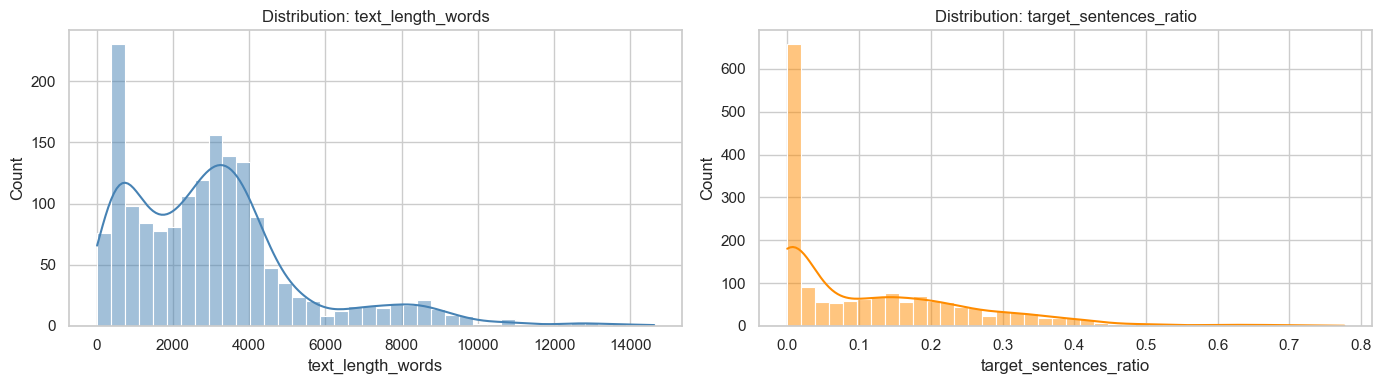

Overall role frequencies (including null):


,count,share
role,,
Governor,713,0.420649
None,388,0.228909
Vice Chairman,299,0.176401
Chairman,295,0.174041


Speech-only role frequencies (including null):


,speech_count
role,
Governor,713
Vice Chairman,299
Chairman,295
None,1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(features_df['text_length_words'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution: text_length_words')

sns.histplot(features_df['target_sentences_ratio'], bins=40, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution: target_sentences_ratio')

plt.tight_layout()
plt.show()

role_counts = features_df['role'].value_counts(dropna=False).rename_axis('role').to_frame('count')
role_counts['share'] = role_counts['count'] / role_counts['count'].sum()

speech_role_counts = (
    features_df.loc[features_df['source_type'] == 'speech', 'role']
    .value_counts(dropna=False)
    .rename_axis('role')
    .to_frame('speech_count')
)

print('Overall role frequencies (including null):')
display(role_counts)
print('Speech-only role frequencies (including null):')
display(speech_role_counts)


## 3) Monthly Aggregation (No Lookahead)

This section builds monthly features for EDA, including event-style sentiment features:
- `hawkish_score_max_abs_signed_7d`
- `hawkish_score_max_abs_signed_14d`
- `hawkish_score_max_abs_signed_30d`

Definition: for each feature month, within trailing x days ending at month-end, select the `hawkish_score` with the largest absolute value while preserving sign.


In [6]:
ROLE_CANONICAL = ['chairman', 'vice_chairman', 'governor']
ROLE_ALIASES = {
    'chairman': {'chairman', 'chair', 'fed chair'},
    'vice_chairman': {'vice_chairman', 'vice chairman', 'vice-chairman', 'vice chair'},
    'governor': {'governor', 'board governor', 'member'},
}


def normalize_role(value: object) -> str | None:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    txt = str(value).strip().lower().replace('-', ' ').replace('_', ' ')
    txt = ' '.join(txt.split())
    if not txt:
        return None

    for canonical, aliases in ROLE_ALIASES.items():
        if txt in aliases:
            return canonical
    return txt.replace(' ', '_')


def monthly_max_abs_signed_hawkish(features: pd.DataFrame, window_days: int) -> pd.DataFrame:
    base = features[['doc_id', 'date', 'hawkish_score']].copy()
    base['feature_month'] = base['date'].dt.to_period('M')

    rows = []
    for feature_month, month_df in base.groupby('feature_month', sort=True):
        month_end = feature_month.to_timestamp(how='end').normalize()
        window_start = month_end - pd.Timedelta(days=window_days - 1)

        window_df = month_df[(month_df['date'] >= window_start) & (month_df['date'] <= month_end)].copy()
        if window_df.empty:
            rows.append({
                'feature_month': feature_month,
                f'hawkish_score_max_abs_signed_{window_days}d': np.nan,
            })
            continue

        winner = (
            window_df
            .assign(abs_score=window_df['hawkish_score'].abs())
            .sort_values(['abs_score', 'date', 'doc_id'], ascending=[False, False, False])
            .iloc[0]
        )

        rows.append({
            'feature_month': feature_month,
            f'hawkish_score_max_abs_signed_{window_days}d': float(winner['hawkish_score']),
        })

    return pd.DataFrame(rows).sort_values('feature_month').reset_index(drop=True)


features_tmp = features_df.copy()
features_tmp['feature_month'] = features_tmp['date'].dt.to_period('M')
features_tmp['source_type_norm'] = features_tmp['source_type'].astype(str).str.upper().str.strip()
features_tmp['role_norm'] = features_tmp['role'].map(normalize_role)

base_monthly = (
    features_tmp.groupby('feature_month')
    .agg(
        hawkish_score=('hawkish_score', 'mean'),
        novelty=('novelty', 'mean'),
        n_hawkish=('n_hawkish', 'sum'),
        n_dovish=('n_dovish', 'sum'),
        n_neutral=('n_neutral', 'sum'),
        n_target_sentences=('n_target_sentences', 'sum'),
        doc_count=('doc_id', 'count'),
        text_length_words_mean=('text_length_words', 'mean'),
        text_length_words_median=('text_length_words', 'median'),
        text_length_words_max=('text_length_words', 'max'),
        target_sentences_ratio_mean=('target_sentences_ratio', 'mean'),
    )
    .reset_index()
    .sort_values('feature_month')
    .reset_index(drop=True)
)

speech_tmp = features_tmp[features_tmp['source_type_norm'] == 'SPEECH'].copy()
role_monthly = (
    speech_tmp.groupby('feature_month')
    .agg(speech_doc_count=('doc_id', 'count'))
    .reset_index()
)

for role_name in ROLE_CANONICAL:
    role_counts = (
        speech_tmp[speech_tmp['role_norm'] == role_name]
        .groupby('feature_month')
        .size()
        .rename(f'role_count_{role_name}')
        .reset_index()
    )
    role_monthly = role_monthly.merge(role_counts, on='feature_month', how='left')

for col in role_monthly.columns:
    if col.startswith('role_count_'):
        role_monthly[col] = role_monthly[col].fillna(0)
        share_col = col.replace('role_count_', 'role_share_')
        role_monthly[share_col] = np.where(
            role_monthly['speech_doc_count'] > 0,
            role_monthly[col] / role_monthly['speech_doc_count'],
            np.nan,
        )

event_7 = monthly_max_abs_signed_hawkish(features_df, 7)
event_14 = monthly_max_abs_signed_hawkish(features_df, 14)
event_30 = monthly_max_abs_signed_hawkish(features_df, 30)

features_monthly = base_monthly.merge(role_monthly, on='feature_month', how='left')
features_monthly = features_monthly.merge(event_7, on='feature_month', how='left')
features_monthly = features_monthly.merge(event_14, on='feature_month', how='left')
features_monthly = features_monthly.merge(event_30, on='feature_month', how='left')

target_monthly = (
    target_df.assign(target_month=target_df['date'].dt.to_period('M'))
    .groupby('target_month')
    .agg(
        t5yie_diff1=('t5yie_diff1', 'mean'),
        t5yie_diff1_abs_mean=('t5yie_diff1', lambda s: s.abs().mean()),
        t5yie_obs=('t5yie_diff1', 'size'),
    )
    .reset_index()
    .sort_values('target_month')
    .reset_index(drop=True)
)

monthly_eda = target_monthly[['target_month', 't5yie_diff1', 't5yie_diff1_abs_mean', 't5yie_obs']].copy()
monthly_eda['feature_month_used'] = monthly_eda['target_month'] - 1
monthly_eda = (
    monthly_eda
    .merge(features_monthly, left_on='feature_month_used', right_on='feature_month', how='left')
    .drop(columns=['feature_month'])
    .sort_values('target_month')
    .reset_index(drop=True)
)

# No-lookahead and shape assertions
assert (monthly_eda['feature_month_used'] < monthly_eda['target_month']).all(), 'No-lookahead check failed'
assert len(monthly_eda) == len(target_monthly), 'Monthly merge row mismatch'

print('monthly target rows:', len(target_monthly))
print('monthly feature rows:', len(features_monthly))
print('monthly aligned rows:', len(monthly_eda))

display(monthly_eda.head(8))



monthly target rows: 279
monthly feature rows: 316
monthly aligned rows: 279


,target_month,t5yie_diff1,t5yie_diff1_abs_mean,t5yie_obs,feature_month_used,hawkish_score,novelty,n_hawkish,n_dovish,n_neutral,n_target_sentences,doc_count,text_length_words_mean,text_length_words_median,text_length_words_max,target_sentences_ratio_mean,speech_doc_count,role_count_chairman,role_count_vice_chairman,role_count_governor,role_share_chairman,role_share_vice_chairman,role_share_governor,hawkish_score_max_abs_signed_7d,hawkish_score_max_abs_signed_14d,hawkish_score_max_abs_signed_30d
0,2003-01,0.009500,0.035500,20,2002-12,0.0,0.113067,0.0,0.0,1.0,1.0,1.0,476.0,476.0,476.0,0.058824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2003-02,0.013684,0.033684,19,2003-01,0.0,0.204370,0.0,0.0,1.0,1.0,1.0,475.0,475.0,475.0,0.062500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2,2003-03,-0.004762,0.052381,21,2003-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2003-04,-0.009524,0.028571,21,2003-03,0.0,0.144288,0.0,0.0,1.0,1.0,1.0,532.0,532.0,532.0,0.050000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2003-05,-0.009048,0.050000,21,2003-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2003-06,0.009048,0.026190,21,2003-05,-1.0,0.167235,0.0,1.0,0.0,1.0,1.0,521.0,521.0,521.0,0.050000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0
6,2003-07,0.013636,0.032727,22,2003-06,-1.0,0.151147,0.0,2.0,0.0,2.0,1.0,605.0,605.0,605.0,0.080000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,-1.0,-1.0
7,2003-08,0.011429,0.034286,21,2003-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Missingness semantics (same convention as existing T5YIE EDA workflow)

MONTHLY_FEATURE_COLS = [
    'hawkish_score', 'novelty', 'n_hawkish', 'n_dovish', 'n_neutral', 'n_target_sentences', 'doc_count',
    'text_length_words_mean', 'text_length_words_median', 'text_length_words_max',
    'target_sentences_ratio_mean', 'speech_doc_count',
    'role_share_chairman', 'role_share_vice_chairman', 'role_share_governor',
    'hawkish_score_max_abs_signed_7d', 'hawkish_score_max_abs_signed_14d', 'hawkish_score_max_abs_signed_30d'
]

months_with_docs = set(features_monthly.loc[features_monthly['doc_count'] > 0, 'feature_month'])
assert len(months_with_docs) > 0, 'No months with docs found'
first_feature_month = min(months_with_docs)

monthly_eda['missing_period_reason'] = np.select(
    [
        monthly_eda['feature_month_used'] < first_feature_month,
        ~monthly_eda['feature_month_used'].isin(months_with_docs),
    ],
    ['pre_feature_history', 'no_docs_month'],
    default='residual_true_gap',
)

missing_rows = []
for col in MONTHLY_FEATURE_COLS:
    miss = monthly_eda[col].isna()
    counts = monthly_eda.loc[miss, 'missing_period_reason'].value_counts()
    assert int(counts.sum()) == int(miss.sum())
    for reason, count in counts.items():
        missing_rows.append({'feature': col, 'reason': reason, 'count': int(count)})

missing_df = pd.DataFrame(missing_rows)
display(missing_df.sort_values(['feature', 'count'], ascending=[True, False]))


,feature,reason,count
6,doc_count,no_docs_month,14
0,hawkish_score,no_docs_month,14
21,hawkish_score_max_abs_signed_14d,residual_true_gap,38
22,hawkish_score_max_abs_signed_14d,no_docs_month,14
23,hawkish_score_max_abs_signed_30d,no_docs_month,14
19,hawkish_score_max_abs_signed_7d,residual_true_gap,91
20,hawkish_score_max_abs_signed_7d,no_docs_month,14
3,n_dovish,no_docs_month,14
2,n_hawkish,no_docs_month,14
4,n_neutral,no_docs_month,14


## 4) Relationship Diagnostics

Focus:
- Compare new features with existing sentiment/text aggregates.
- Evaluate possible redundancy and distinctiveness.
- Inspect relationships with `t5yie_diff1` (Pearson + Spearman).


,pearson,spearman,abs_pearson,abs_spearman,best_abs_corr
hawkish_score,-0.113032,-0.189702,0.113032,0.189702,0.189702
novelty,-0.069985,-0.111287,0.069985,0.111287,0.111287
text_length_words_max,0.036989,0.109519,0.036989,0.109519,0.109519
hawkish_score_max_abs_signed_14d,-0.030138,-0.091330,0.030138,0.091330,0.091330
role_share_chairman,-0.083443,0.006571,0.083443,0.006571,0.083443
hawkish_score_max_abs_signed_30d,-0.063480,-0.083229,0.063480,0.083229,0.083229
hawkish_score_max_abs_signed_7d,-0.031462,-0.082229,0.031462,0.082229,0.082229
text_length_words_median,-0.034422,-0.070434,0.034422,0.070434,0.070434
target_sentences_ratio_mean,-0.054136,-0.067113,0.054136,0.067113,0.067113
doc_count,-0.064560,-0.050289,0.064560,0.050289,0.064560


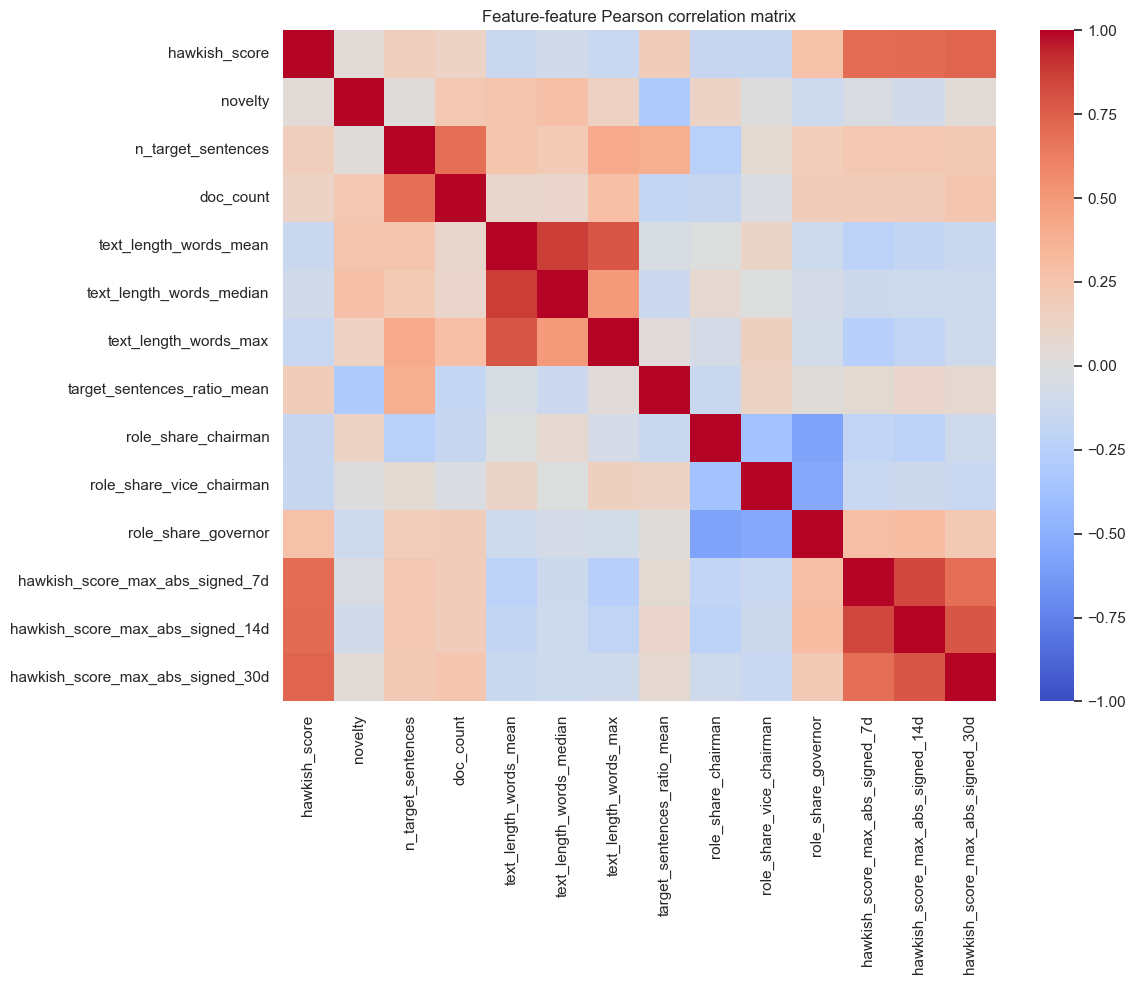

In [8]:
analysis_cols = [
    't5yie_diff1',
    'hawkish_score', 'novelty', 'n_target_sentences', 'doc_count',
    'text_length_words_mean', 'text_length_words_median', 'text_length_words_max',
    'target_sentences_ratio_mean',
    'role_share_chairman', 'role_share_vice_chairman', 'role_share_governor',
    'hawkish_score_max_abs_signed_7d', 'hawkish_score_max_abs_signed_14d', 'hawkish_score_max_abs_signed_30d'
]

corr_df = monthly_eda[analysis_cols].copy()

pearson = corr_df.corr(method='pearson', numeric_only=True)['t5yie_diff1'].drop('t5yie_diff1')
spearman = corr_df.corr(method='spearman', numeric_only=True)['t5yie_diff1'].drop('t5yie_diff1')

signal_summary = (
    pd.DataFrame({'pearson': pearson, 'spearman': spearman})
    .assign(
        abs_pearson=lambda d: d['pearson'].abs(),
        abs_spearman=lambda d: d['spearman'].abs(),
        best_abs_corr=lambda d: d[['abs_pearson', 'abs_spearman']].max(axis=1),
    )
    .sort_values('best_abs_corr', ascending=False)
)

display(signal_summary)

feature_feature_corr = corr_df.drop(columns=['t5yie_diff1']).corr(method='pearson', numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(feature_feature_corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Feature-feature Pearson correlation matrix')
plt.tight_layout()
plt.show()


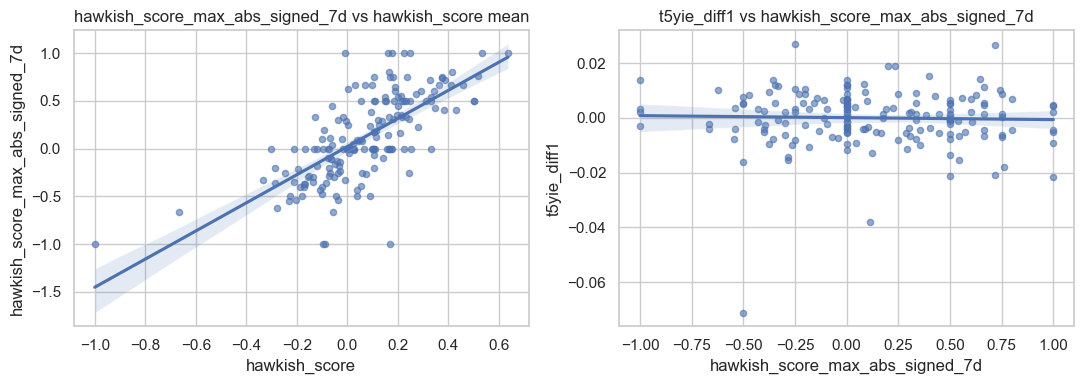

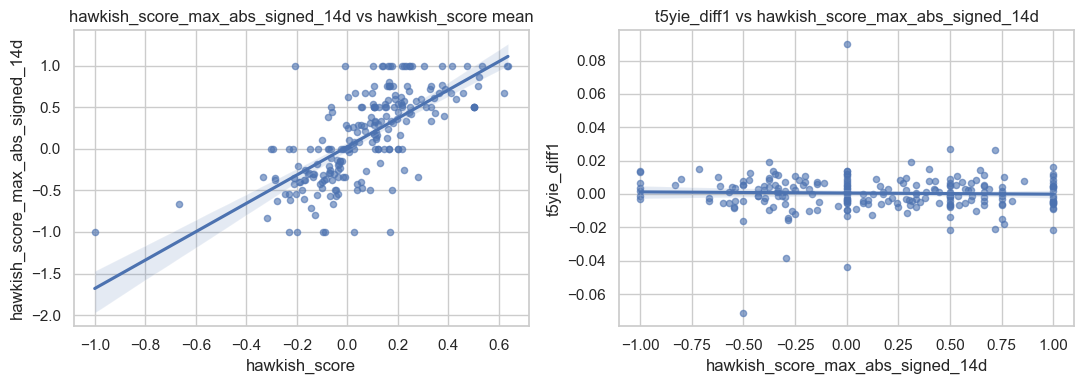

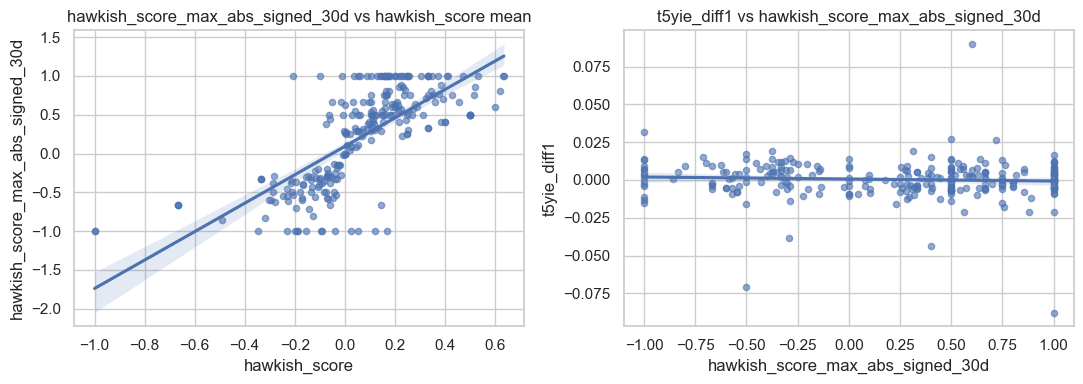

,feature,corr_with_hawkish_score_mean,corr_with_target,note
0,hawkish_score_max_abs_signed_7d,0.700588,-0.031462,ok
1,hawkish_score_max_abs_signed_14d,0.704565,-0.030138,ok
2,hawkish_score_max_abs_signed_30d,0.730265,-0.063480,ok


In [9]:
# Distinct-information checks: event-style vs monthly mean hawkish score

event_cols = [
    'hawkish_score_max_abs_signed_7d',
    'hawkish_score_max_abs_signed_14d',
    'hawkish_score_max_abs_signed_30d',
]

distinct_rows = []
for col in event_cols:
    pair = monthly_eda[['hawkish_score', col, 't5yie_diff1']].dropna()
    if pair.empty:
        distinct_rows.append({
            'feature': col,
            'corr_with_hawkish_score_mean': np.nan,
            'corr_with_target': np.nan,
            'note': 'insufficient_overlap',
        })
        continue

    corr_with_mean = pair[['hawkish_score', col]].corr().iloc[0, 1]
    corr_with_target = pair[[col, 't5yie_diff1']].corr().iloc[0, 1]
    distinct_rows.append({
        'feature': col,
        'corr_with_hawkish_score_mean': corr_with_mean,
        'corr_with_target': corr_with_target,
        'note': 'ok',
    })

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.regplot(data=pair, x='hawkish_score', y=col, ax=axes[0], scatter_kws={'s': 20, 'alpha': 0.6})
    axes[0].set_title(f'{col} vs hawkish_score mean')

    sns.regplot(data=pair, x=col, y='t5yie_diff1', ax=axes[1], scatter_kws={'s': 20, 'alpha': 0.6})
    axes[1].set_title(f't5yie_diff1 vs {col}')

    plt.tight_layout()
    plt.show()


distinct_df = pd.DataFrame(distinct_rows)
display(distinct_df)


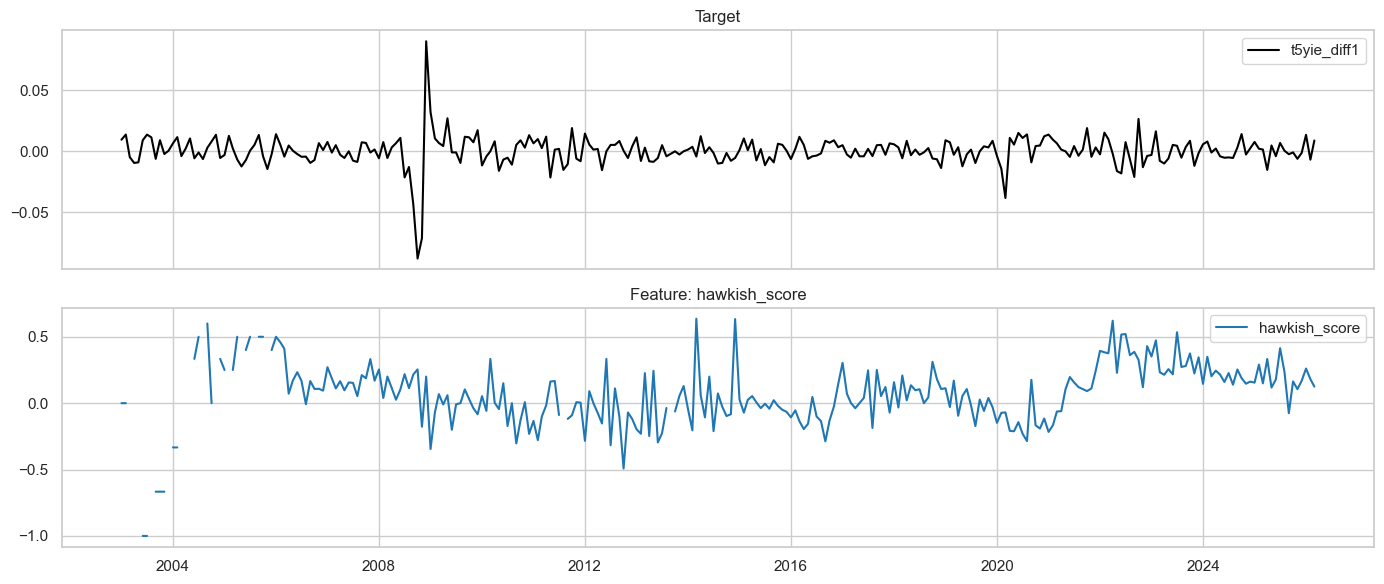

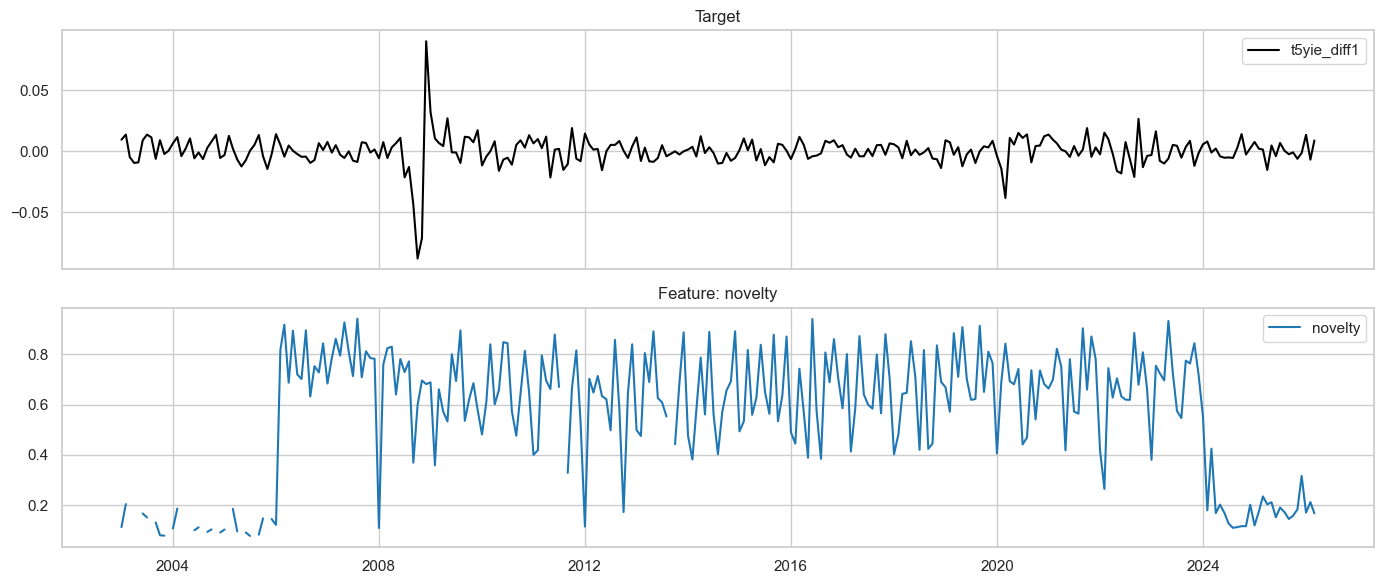

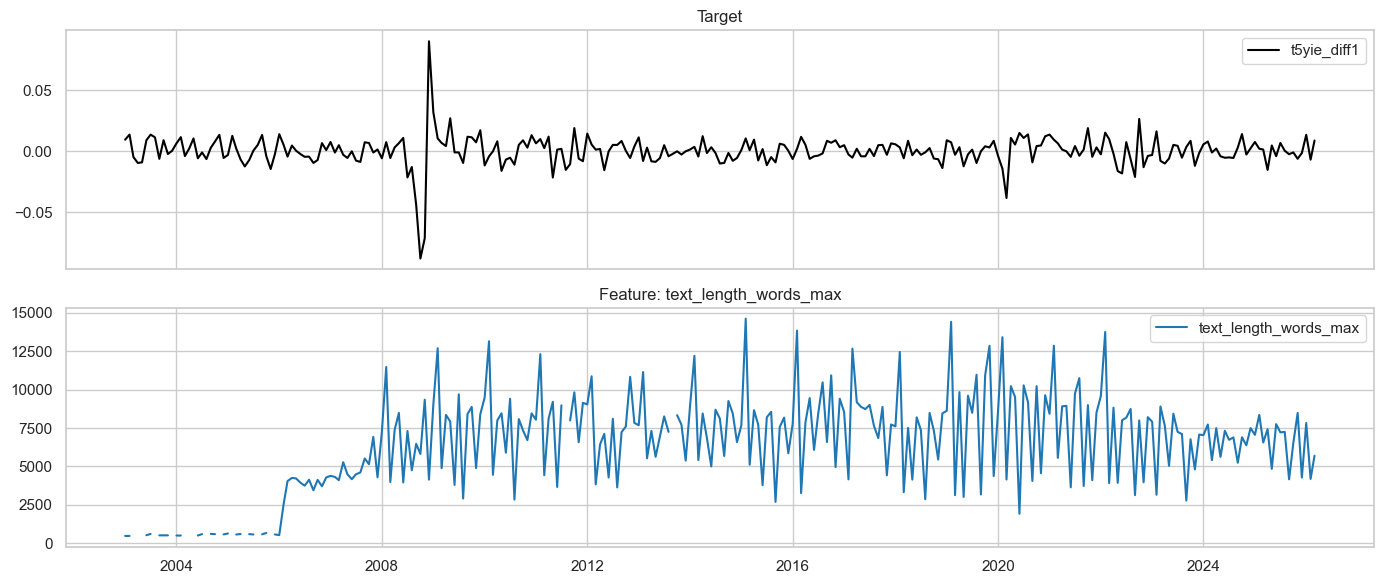

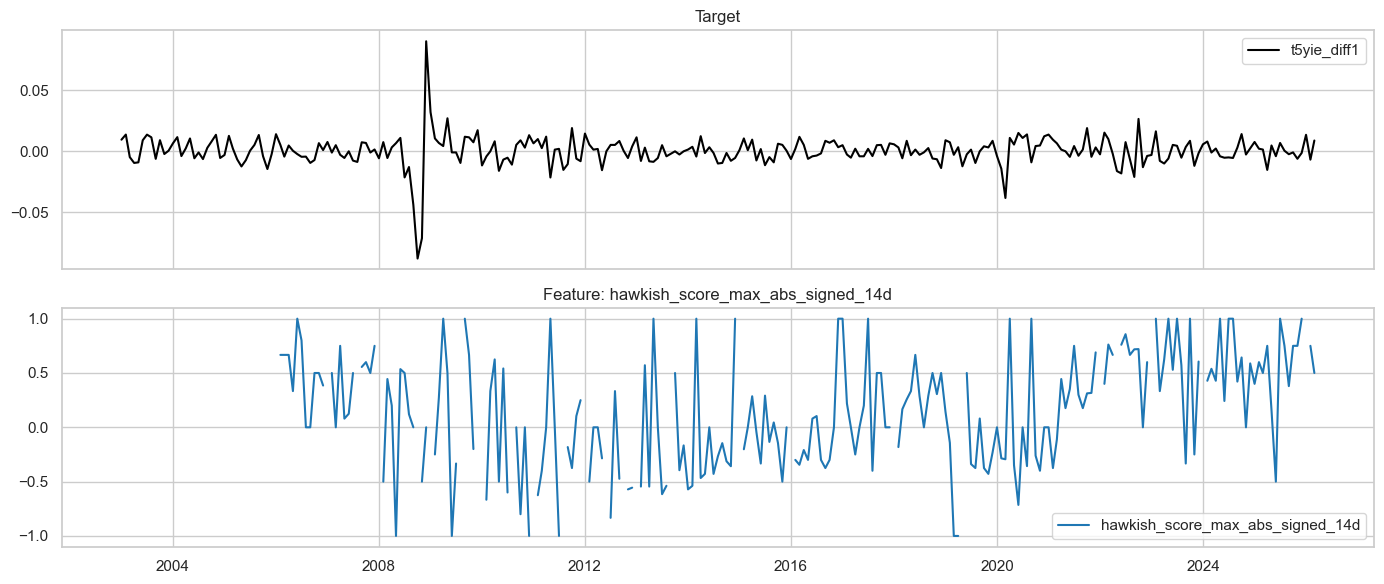

In [10]:
# Time overlays for top features by absolute correlation

top_features = signal_summary.head(4).index.tolist()
plot_df = monthly_eda.copy()
plot_df['month_start'] = plot_df['target_month'].dt.to_timestamp()

for feat in top_features:
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(plot_df['month_start'], plot_df['t5yie_diff1'], color='black', label='t5yie_diff1')
    axes[0].legend()
    axes[0].set_title('Target')

    axes[1].plot(plot_df['month_start'], plot_df[feat], color='tab:blue', label=feat)
    axes[1].legend()
    axes[1].set_title(f'Feature: {feat}')

    plt.tight_layout()
    plt.show()


## 5) Role Feature Feasibility

Role is intentionally kept lightweight. This section checks whether role-share features are usable or too sparse/noisy.


In [11]:
role_cols = ['role_share_chairman', 'role_share_vice_chairman', 'role_share_governor']

role_coverage = pd.DataFrame({
    'non_null_rate': monthly_eda[role_cols].notna().mean(),
    'zero_rate': (monthly_eda[role_cols] == 0).mean(),
    'std': monthly_eda[role_cols].std(numeric_only=True),
})

speech_months = monthly_eda['speech_doc_count'].fillna(0)
role_sparse_flag = (
    (speech_months.gt(0).mean() < 0.5)
    or (role_coverage['non_null_rate'].min() < 0.5)
    or (role_coverage['std'].max() < 0.03)
)

print('share of months with at least one speech doc:', float(speech_months.gt(0).mean()))
print('role_sparse_flag:', bool(role_sparse_flag))
display(role_coverage)


share of months with at least one speech doc: 0.8422939068100358
role_sparse_flag: False


,non_null_rate,zero_rate,std
role_share_chairman,0.842294,0.254480,0.245897
role_share_vice_chairman,0.842294,0.286738,0.241329
role_share_governor,0.842294,0.093190,0.273131


## 6) Decision Section

Classify each candidate feature as:
- `promising`
- `weak`
- `redundant`
- `too sparse/noisy`

This is for experiment prioritization only (not causal inference).


In [12]:
base_reference = {'hawkish_score', 'novelty', 'n_target_sentences', 'doc_count'}
candidate_features = [
    'text_length_words_mean', 'text_length_words_median', 'text_length_words_max',
    'target_sentences_ratio_mean',
    'role_share_chairman', 'role_share_vice_chairman', 'role_share_governor',
    'hawkish_score_max_abs_signed_7d', 'hawkish_score_max_abs_signed_14d', 'hawkish_score_max_abs_signed_30d',
]

upper = feature_feature_corr.where(np.triu(np.ones(feature_feature_corr.shape), k=1).astype(bool))
redundant_pairs = upper.stack().reset_index().rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'corr'})
redundant_pairs['abs_corr'] = redundant_pairs['corr'].abs()


def status_for_feature(f: str) -> str:
    best_abs = float(signal_summary['best_abs_corr'].get(f, np.nan))

    if f.startswith('role_share_') and role_sparse_flag:
        return 'too sparse/noisy'

    if f.startswith('hawkish_score_max_abs_signed_'):
        row = distinct_df.loc[distinct_df['feature'] == f]
        if not row.empty:
            corr_with_mean = float(row['corr_with_hawkish_score_mean'].iloc[0])
            corr_with_target = float(abs(row['corr_with_target'].iloc[0]))
            base_target = float(signal_summary.loc['hawkish_score', 'best_abs_corr'])
            if np.isfinite(corr_with_mean) and abs(corr_with_mean) >= 0.95 and corr_with_target <= (base_target + 0.005):
                return 'redundant'

    # Generic redundancy check against baseline references.
    refs = redundant_pairs[(redundant_pairs['feature_a'] == f) & (redundant_pairs['feature_b'].isin(base_reference))]
    refs2 = redundant_pairs[(redundant_pairs['feature_b'] == f) & (redundant_pairs['feature_a'].isin(base_reference))]
    max_ref_corr = pd.concat([refs['abs_corr'], refs2['abs_corr']], ignore_index=True)
    max_ref_corr = float(max_ref_corr.max()) if not max_ref_corr.empty else np.nan

    if np.isfinite(max_ref_corr) and max_ref_corr >= 0.9 and best_abs < 0.05:
        return 'redundant'

    if best_abs >= 0.08:
        return 'promising'
    if best_abs >= 0.04:
        return 'weak'
    return 'weak'


decision_rows = []
for f in candidate_features:
    decision_rows.append({
        'feature': f,
        'best_abs_corr': float(signal_summary['best_abs_corr'].get(f, np.nan)),
        'status': status_for_feature(f),
    })

decision_df = pd.DataFrame(decision_rows).sort_values(['status', 'best_abs_corr'], ascending=[True, False])
carry_forward = decision_df.loc[decision_df['status'] == 'promising', 'feature'].tolist()

print('Decision table:')
display(decision_df)
print('Carry-forward shortlist:', carry_forward)


Decision table:


,feature,best_abs_corr,status
2,text_length_words_max,0.109519,promising
8,hawkish_score_max_abs_signed_14d,0.091330,promising
4,role_share_chairman,0.083443,promising
9,hawkish_score_max_abs_signed_30d,0.083229,promising
7,hawkish_score_max_abs_signed_7d,0.082229,promising
1,text_length_words_median,0.070434,weak
3,target_sentences_ratio_mean,0.067113,weak
6,role_share_governor,0.040235,weak
0,text_length_words_mean,0.039070,weak
5,role_share_vice_chairman,0.034103,weak


Carry-forward shortlist: ['text_length_words_max', 'hawkish_score_max_abs_signed_14d', 'role_share_chairman', 'hawkish_score_max_abs_signed_30d', 'hawkish_score_max_abs_signed_7d']


In [13]:
print('Short Plain-English Summary')
print('=' * 90)
print('This EDA evaluates new text/role features and event-style sentiment windows under strict no-lookahead monthly alignment.')
print('Most promising features:', carry_forward)

if role_sparse_flag:
    print('Role feature note: role-share signals are sparse/noisy in this dataset and should remain low-priority for modeling.')
else:
    print('Role feature note: role-share signals show usable coverage; keep as optional candidates.')

print('Event-style note: `hawkish_score_max_abs_signed_xd` was evaluated in-notebook only (no production schema changes in this pass).')


Short Plain-English Summary
This EDA evaluates new text/role features and event-style sentiment windows under strict no-lookahead monthly alignment.
Most promising features: ['text_length_words_max', 'hawkish_score_max_abs_signed_14d', 'role_share_chairman', 'hawkish_score_max_abs_signed_30d', 'hawkish_score_max_abs_signed_7d']
Role feature note: role-share signals show usable coverage; keep as optional candidates.
Event-style note: `hawkish_score_max_abs_signed_xd` was evaluated in-notebook only (no production schema changes in this pass).


## 7) Reproducibility Checks

Core deterministic checks are repeated here to support clean reruns.


In [14]:
# Deterministic ordering and no-lookahead checks
assert target_df['date'].is_monotonic_increasing
assert target_df['date'].is_unique
assert features_df['date'].is_monotonic_increasing
assert monthly_eda['target_month'].is_monotonic_increasing
assert (monthly_eda['feature_month_used'] < monthly_eda['target_month']).all()

# Stable row count checks
assert len(monthly_eda) == len(target_monthly)
assert len(features_monthly) == features_df['date'].dt.to_period('M').nunique()

# Event-window columns present
for c in ['hawkish_score_max_abs_signed_7d', 'hawkish_score_max_abs_signed_14d', 'hawkish_score_max_abs_signed_30d']:
    assert c in monthly_eda.columns

print('All reproducibility and integrity checks passed.')


All reproducibility and integrity checks passed.
